# MWE of Natural Gradient Descent with Zodiax

I want to demonstrate how to implement Fisher pre-conditioning, or natural gradient descent (NGD), with a simple Zodiax toy model.

NDG is the rescaling of the gradients during gradient descent by the covariance matrix which best approximates the loss space. We can compute this matrix in Zodiax (it's just a hessian)!

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import zodiax as zdx

from jax import numpy as np, scipy as jsp, random as jr
import matplotlib.pyplot as plt

NGD is advantageous when the parameter space is covariant, so I will choose a toy model with covariant parameters.

I have chosen a 1D Gaussian distribution, where the amplitude `amp` and width `stdev` are the covariant parameters. Here I implement a simple 1D Gaussian into a Zodiax model.

In [2]:
class Gaussian(zdx.Base):
    """
    Model of a simple one-dimensional Gaussian distribution.
    """

    amp: jax.Array
    mu: jax.Array
    stdev: jax.Array

    def __init__(self, amp, mu, stdev):
        self.amp = np.array(amp)
        self.mu = np.array(mu)
        self.stdev = np.array(stdev)

    def model(self, x):
        return self.amp * jsp.stats.norm.pdf(x, loc=self.mu, scale=self.stdev)

Here I am generated the fake data used in the fitting loops later.

In [3]:
# truth model
true_params = {"amp": 30.0, "mu": 1.0e4, "stdev": 2e-1}
true_model = Gaussian(**true_params)

# generating some synthetic data from the truth model
xs = true_params["mu"] + true_params["stdev"] * np.linspace(-5, 5, 100)
ys = true_model.model(xs)
data = ys + 0.4 * np.sqrt(ys) * jr.normal(jr.PRNGKey(0), ys.shape)

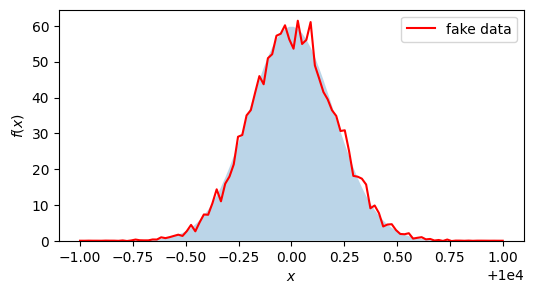

In [4]:
# plotting
plt.figure(figsize=(6, 3))
plt.fill_between(xs, ys, alpha=0.3)
plt.plot(xs, data, color="red", label="fake data")
plt.ylim(0, None)
plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")
plt.legend()
plt.show()

## Without Natural Gradient Descent
First I will optimise this model without NGD.

In [5]:
from zodiax.optimisation import sgd


opt_parameters = ["amp", "stdev"]  # parameters to optimise
optimisers = {
    "amp": sgd(1e-3, 0),
    "stdev": sgd(1e-7, 0),
}

# initial guess
init_guess = {
    "amp": 1.05 * true_model.amp,
    "mu": true_model.mu,
    "stdev": 0.999 * true_model.stdev,
}

Defining loss function, just a simple squared differences.

In [6]:
@zdx.filter_jit
def log_likelihood(model, data):
    return np.square(model.model(xs) - data).sum()


@zdx.filter_jit
@zdx.filter_value_and_grad(opt_parameters)
def loss_fn(model, data):
    return log_likelihood(model, data)

Optimising...

In [7]:
# Evaluate loss function once Compile to XLA
init_model = Gaussian(**init_guess)
loss, grads = loss_fn(init_model, data)

# Get optax objcets
optimiser, state = zdx.get_optimiser(
    init_model, list(optimisers.keys()), list(optimisers.values())
)

losses = []
model = init_model
models = [model]
for i in range(30):
    loss, grads = loss_fn(model, data)
    step, state = optimiser.update(grads, state)
    model = zdx.apply_updates(model, step)

    losses.append(loss)
    models.append(model)

Let's look at the fit.

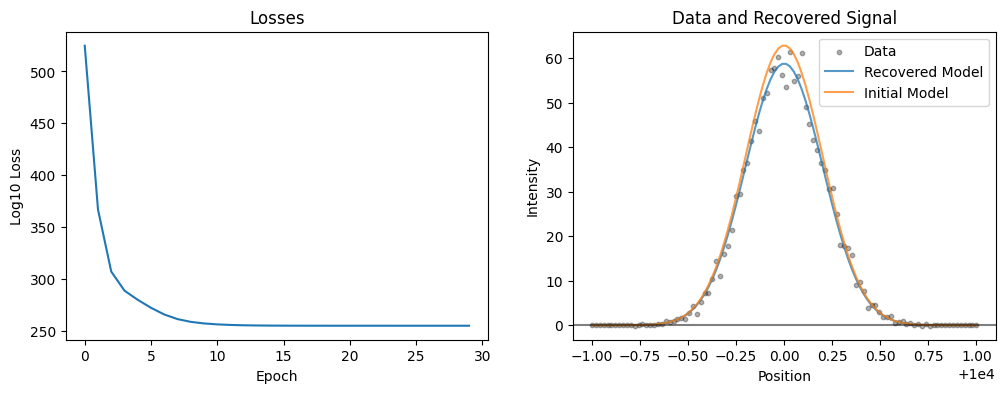

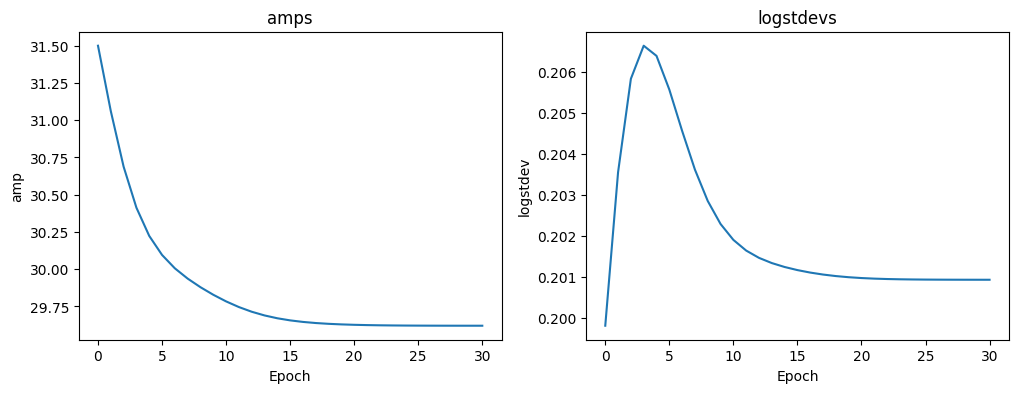

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.array(losses))
plt.title("Losses")
plt.xlabel("Epoch")
plt.ylabel("Log10 Loss")

plt.subplot(1, 2, 2)
plt.scatter(xs, data, s=10, label="Data", color="k", alpha=0.3)
plt.plot(xs, model.model(xs), alpha=0.75, label="Recovered Model")
plt.plot(xs, init_model.model(xs), alpha=0.75, label="Initial Model")
plt.axhline(0, color="k", alpha=0.5)
plt.title("Data and Recovered Signal")
plt.xlabel("Position")
plt.ylabel("Intensity")
plt.legend()
plt.show()


# parameter curves
amps = [m.amp for m in models]
# mus = [m.mu for m in models]
stdevs = [m.stdev for m in models]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(amps)
plt.title("amps")
plt.xlabel("Epoch")
plt.ylabel("amp")

plt.subplot(1, 2, 2)
plt.plot(stdevs)
plt.title("logstdevs")
plt.xlabel("Epoch")
plt.ylabel("logstdev")
plt.show()

Finally, let's look at how our optimisation loop walked through parameter space.

In [9]:
n_pts = 1000
test_amps = true_model.amp + np.linspace(-2, 2, n_pts)
# test_mus = true_params["mu"] + np.linspace(-0.5, 0.5, n_pts)
test_stdevs = true_model.stdev + np.linspace(-0.02, 0.02, n_pts)

AMP, LOGSTD = np.meshgrid(test_amps, test_stdevs)


# Define a single-point log-likelihood function
def eval_loglike(amp, stdev):
    m = model.set(["amp", "stdev"], [amp, stdev])
    return log_likelihood(m, data)


# Fully vectorised evaluation using jax.vmap over both axes
loglike_grid = jax.vmap(
    lambda logstd_row: jax.vmap(lambda amp: eval_loglike(amp, logstd_row))(test_amps)
)(test_stdevs)
likelihood_grid = np.exp(-0.5 * loglike_grid)

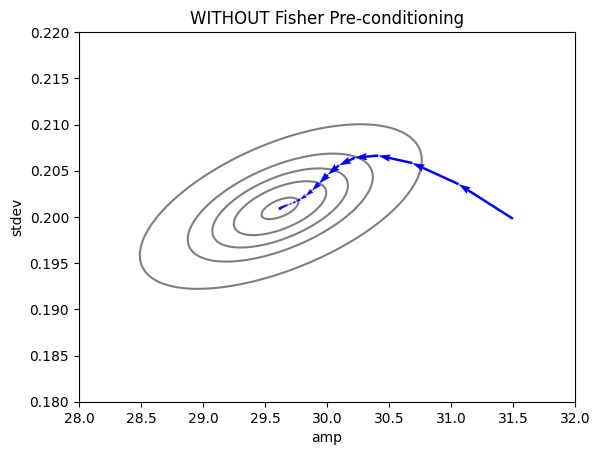

In [10]:
# Plot
fig, ax = plt.subplots()
gamma = 10
levels = (np.linspace(0.05, 0.95, 5) ** gamma) * np.max(likelihood_grid)
im = ax.contour(
    AMP, LOGSTD, likelihood_grid, levels=levels, zorder=-10, colors="k", alpha=0.5
)
# ax.axvline(true_params["amp"], c="red", alpha=0.1, linestyle="dashed", zorder=-100)
# # ax.axvline(true_params["mu"], c="red", alpha=0.1, linestyle="dashed", zorder=-100)
# ax.axhline(true_model.stdev, c="red", alpha=0.1, linestyle="dashed", zorder=-100)

amps = [m.amp for m in models]
# mus = [m.mu for m in models]
stdevs = [m.stdev for m in models]
amps_arr = np.array(amps)
# mus_arr = np.array(mus)
stdevs_arr = np.array(stdevs)


# ax.scatter(mus_arr, logstdevs_arr, s=20, color="k", zorder=5)
ax.quiver(
    amps_arr[:-1],
    stdevs_arr[:-1],
    amps_arr[1:] - amps_arr[:-1],
    stdevs_arr[1:] - stdevs_arr[:-1],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.005,
    color="blue",
    zorder=6,
)

ax.set(
    xlabel="amp",
    ylabel="stdev",
    title="WITHOUT Fisher Pre-conditioning",
    xlim=(test_amps.min(), test_amps.max()),
    ylim=(test_stdevs.min(), test_stdevs.max()),
)
# ax.legend()
# fig.colorbar(im)
plt.show()

## With Natural Gradient Descent

Okay, so now let's repeat but implement NGD. We will need to calculate the (negative) covariance matrix for our loss space. We can do this using the `zdx.fisher.covariance_matrix` function, which is just a wrapper around the `zdx.fisher.hessian` function. So effectively what we are calculating is the inverse positive hessian.

In [11]:
cov_mat = -zdx.fisher.covariance_matrix(
    true_model, opt_parameters, log_likelihood, data
)

Now, rinse and repeat. Notice the learning rates I had to choose are a lot more reasonable. Just using a learning rate of 1 is normally good enough, but you can play it safe by softening it by a factor of 2. I chose `1e-1` just so it was easier to see the path the walker takes through the loss space.

In [12]:
optimisers = {
    "amp": sgd(1e-1, 0),
    "stdev": sgd(1e-1, 0),
}


# Evaluate loss function once Compile to XLA
init_model = Gaussian(**init_guess)
loss, grads = loss_fn(init_model, data)

# Get optax objcets
optimiser, state = zdx.get_optimiser(
    init_model, list(optimisers.keys()), list(optimisers.values())
)

losses = []
models = []
model = init_model
for i in range(30):
    loss, grads = loss_fn(model, data)

    ################# PRE-FISHER CONDITIONING #################
    gs = np.array([grads.amp, grads.stdev])
    gs = cov_mat @ gs  # matrix multiplication
    grads = grads.set(["amp", "stdev"], [gs[0], gs[1]])
    ###########################################################

    step, state = optimiser.update(grads, state)
    model = zdx.apply_updates(model, step)

    losses.append(loss)
    models.append(model)

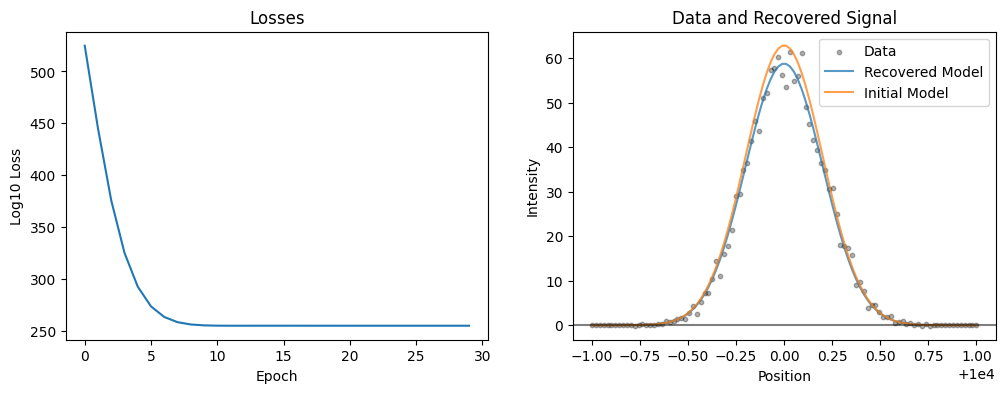

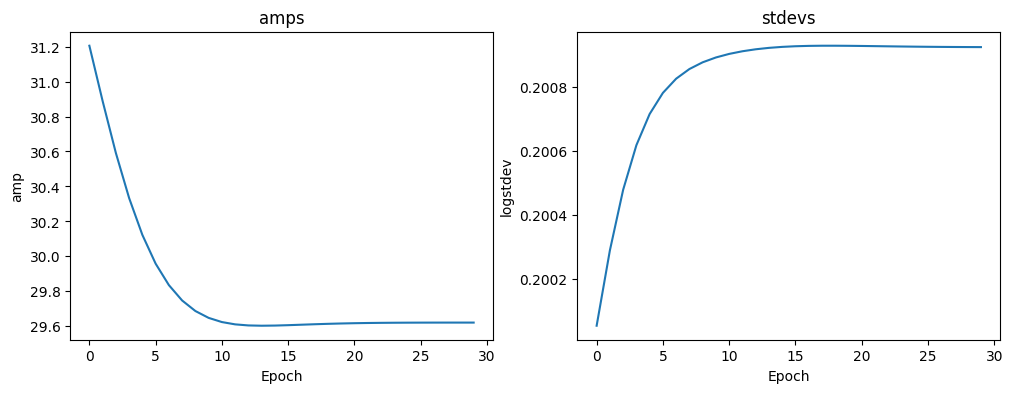

In [13]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.array(losses))
plt.title("Losses")
plt.xlabel("Epoch")
plt.ylabel("Log10 Loss")

plt.subplot(1, 2, 2)
plt.scatter(xs, data, s=10, label="Data", color="k", alpha=0.3)
plt.plot(xs, model.model(xs), alpha=0.75, label="Recovered Model")
plt.plot(xs, init_model.model(xs), alpha=0.75, label="Initial Model")
plt.axhline(0, color="k", alpha=0.5)
plt.title("Data and Recovered Signal")
plt.xlabel("Position")
plt.ylabel("Intensity")
plt.legend()
plt.show()


# parameter curves
amps = [m.amp for m in models]
stdevs = [m.stdev for m in models]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(amps)
plt.title("amps")
plt.xlabel("Epoch")
plt.ylabel("amp")

plt.subplot(1, 2, 2)
plt.plot(stdevs)
plt.title("stdevs")
plt.xlabel("Epoch")
plt.ylabel("logstdev")
plt.show()

In [14]:
n_pts = 1000
test_amps = true_model.amp + np.linspace(-2, 2, n_pts)
test_stdevs = true_model.stdev + np.linspace(-0.02, 0.02, n_pts)

AMP, LOGSTD = np.meshgrid(test_amps, test_stdevs)


# Define a single-point log-likelihood function
def eval_loglike(amp, stdev):
    m = model.set(["amp", "stdev"], [amp, stdev])
    return log_likelihood(m, data)


# Fully vectorised evaluation using jax.vmap over both axes
loglike_grid = jax.vmap(
    lambda logstd_row: jax.vmap(lambda amp: eval_loglike(amp, logstd_row))(test_amps)
)(test_stdevs)
likelihood_grid = np.exp(-0.5 * loglike_grid)

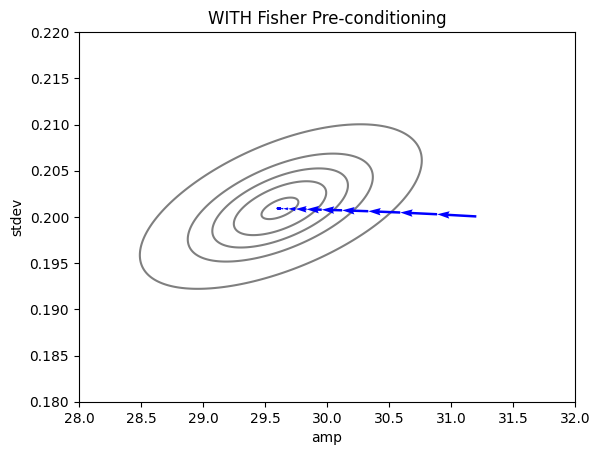

In [15]:
# Plot
amps = [m.amp for m in models]
stdevs = [m.stdev for m in models]
amps_arr = np.array(amps)
stdevs_arr = np.array(stdevs)


fig, ax = plt.subplots()
gamma = 10
levels = (np.linspace(0.05, 0.95, 5) ** gamma) * np.max(likelihood_grid)
im = ax.contour(
    AMP,
    LOGSTD,
    likelihood_grid,
    levels=levels,
    zorder=-10,
    colors="k",
    alpha=0.5,
)
ax.quiver(
    amps_arr[:-1],
    stdevs_arr[:-1],
    amps_arr[1:] - amps_arr[:-1],
    stdevs_arr[1:] - stdevs_arr[:-1],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.005,
    color="blue",
    zorder=6,
    label="Gradient Descent Steps",
)

ax.set(
    xlabel="amp",
    ylabel="stdev",
    title="WITH Fisher Pre-conditioning",
    xlim=(test_amps.min(), test_amps.max()),
    ylim=(test_stdevs.min(), test_stdevs.max()),
)

plt.show()